In [8]:
import pandas as pd

In [9]:
# June datasets (pre-ALIKA)
df_1_5_june = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788146480 (1-5 june).csv', low_memory=False)
df_6_10_june = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788146837 (6-10 june).csv', low_memory=False)
df_11_15_june = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788148372 (11-15 june).csv', low_memory=False)
df_16_20_june = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788149085 (16-20 june).csv', low_memory=False)
df_21_25_june = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788149522 (21-25 june).csv', low_memory=False)
df_26_30_june = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788150625 (26-30 june).csv', low_memory=False)

# August datasets (ALIKA live). Some exports overlap; duplicates are removed later by conversation id.
df_1_5_aug = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788145507 (1-5 aug).csv', low_memory=False)
df_6_10_aug = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788145209 (6-10 aug).csv', low_memory=False)
df_11_14_aug = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788144961 (11-14 aug).csv', low_memory=False)
df_13_15_aug = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1787219325 (13-15 aug).csv', low_memory=False)
df_16_18_aug = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1787025549 (16-18 aug).csv', low_memory=False)
df_19_20_aug = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1787219503 (19-20 aug).csv', low_memory=False)
df_21_26_aug = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788144629 (21-26 aug).csv', low_memory=False)
df_27_31_aug = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788141789 (27-31 aug).csv', low_memory=False)

In [10]:
# Combine exports, then remove overlapping-export duplicates by conversation id.
data_june = pd.concat(
    [df_1_5_june, df_6_10_june, df_11_15_june, df_16_20_june, df_21_25_june, df_26_30_june],
    ignore_index=True,
).drop_duplicates(subset='id')

data_august = pd.concat(
    [df_1_5_aug, df_6_10_aug, df_11_14_aug, df_13_15_aug, df_16_18_aug, df_19_20_aug, df_21_26_aug, df_27_31_aug],
    ignore_index=True,
).drop_duplicates(subset='id')

print(f'Unique June conversations: {len(data_june):,}')
print(f'Unique August conversations: {len(data_august):,}')

Unique June conversations: 351,236
Unique August conversations: 336,720


In [11]:
# Scope strictly to KULA account requested for this analysis.
data_june_clean = data_june.loc[data_june['currentAccount'].eq('3-1-robot2')].copy()
data_august_clean = data_august.loc[data_august['currentAccount'].eq('3-1-robot2')].copy()

for frame, period in [(data_june_clean, 'June (pre-ALIKA)'), (data_august_clean, 'August (ALIKA live)')]:
    frame['period'] = period
    frame['score_num'] = pd.to_numeric(frame['score'], errors='coerce')
    frame['rated'] = frame['score_num'].between(1, 5)
    frame['satisfied'] = frame['score_num'].ge(4)  # CSAT top-two box: scores 4-5
    frame['dislike'] = frame['score_num'].eq(1)   # dislike: score 1
    frame['from_alika'] = frame['changeFlag'].astype('string').str.contains('Alika', case=False, na=False)
    frame['date'] = pd.to_datetime(frame['createTime'], errors='coerce').dt.date

print(f'KULA June conversations: {len(data_june_clean):,}')
print(f'KULA August conversations: {len(data_august_clean):,}')

KULA June conversations: 85,655
KULA August conversations: 179,559


In [12]:
def metric_summary(frame):
    rated = frame.loc[frame['rated']]
    return pd.Series({
        'conversations': len(frame),
        'unique_users': frame['userId'].nunique(),
        'days': frame['date'].nunique(),
        'conversations_per_day': len(frame) / frame['date'].nunique(),
        'rated_conversations': len(rated),
        'rating_response_rate_%': 100 * frame['rated'].mean(),
        'mean_score': rated['score_num'].mean(),
        'CSAT_4_5_%_of_rated': 100 * rated['satisfied'].mean(),
        'dislike_1_%_of_rated': 100 * rated['dislike'].mean(),
        'dislikes_per_1000_conversations': 1000 * frame['dislike'].sum() / len(frame),
    })

period_summary = pd.concat(
    {
        'June (pre-ALIKA)': metric_summary(data_june_clean),
        'August (ALIKA live)': metric_summary(data_august_clean),
    },
    axis=1,
).round(3)
period_summary

,June (pre-ALIKA),August (ALIKA live)
conversations,85655.000,179559.000
unique_users,62928.000,131831.000
days,30.000,31.000
conversations_per_day,2855.167,5792.226
rated_conversations,872.000,1417.000
rating_response_rate_%,1.018,0.789
mean_score,3.334,3.367
CSAT_4_5_%_of_rated,56.881,57.869
dislike_1_%_of_rated,35.894,35.215
dislikes_per_1000_conversations,3.654,2.779


In [13]:
# Separate volume changes from rated-user outcome changes.
comparison = pd.DataFrame({
    'June (pre-ALIKA)': period_summary['June (pre-ALIKA)'],
    'August (ALIKA live)': period_summary['August (ALIKA live)'],
})
comparison['absolute_change'] = comparison['August (ALIKA live)'] - comparison['June (pre-ALIKA)']
comparison['relative_change_%'] = 100 * comparison['absolute_change'] / comparison['June (pre-ALIKA)']
comparison.round(3)

,June (pre-ALIKA),August (ALIKA live),absolute_change,relative_change_%
conversations,85655.000,179559.000,93904.000,109.630
unique_users,62928.000,131831.000,68903.000,109.495
days,30.000,31.000,1.000,3.333
conversations_per_day,2855.167,5792.226,2937.059,102.868
rated_conversations,872.000,1417.000,545.000,62.500
rating_response_rate_%,1.018,0.789,-0.229,-22.495
mean_score,3.334,3.367,0.033,0.990
CSAT_4_5_%_of_rated,56.881,57.869,0.988,1.737
dislike_1_%_of_rated,35.894,35.215,-0.679,-1.892
dislikes_per_1000_conversations,3.654,2.779,-0.875,-23.946


In [14]:
# Significance tests compare rated conversations only.
# They test association, not causality; June and August are observational cohorts.
import numpy as np
from scipy.stats import chi2_contingency, ttest_ind

june_rated = data_june_clean.loc[data_june_clean['rated']]
august_rated = data_august_clean.loc[data_august_clean['rated']]

test_rows = []

welch = ttest_ind(june_rated['score_num'], august_rated['score_num'], equal_var=False)
test_rows.append({
    'metric': 'Mean score',
    'June': june_rated['score_num'].mean(),
    'August': august_rated['score_num'].mean(),
    'difference_pp_or_score': august_rated['score_num'].mean() - june_rated['score_num'].mean(),
    'p_value': welch.pvalue,
})

for column, label in [('satisfied', 'CSAT 4-5 rate'), ('dislike', 'Dislike score-1 rate')]:
    table = np.array([
        [june_rated[column].sum(), (~june_rated[column]).sum()],
        [august_rated[column].sum(), (~august_rated[column]).sum()],
    ])
    p_value = chi2_contingency(table, correction=False).pvalue
    june_rate = 100 * june_rated[column].mean()
    august_rate = 100 * august_rated[column].mean()
    test_rows.append({
        'metric': label,
        'June': june_rate,
        'August': august_rate,
        'difference_pp_or_score': august_rate - june_rate,
        'p_value': p_value,
    })

significance_tests = pd.DataFrame(test_rows).set_index('metric')
significance_tests['statistically_significant_at_0.05'] = significance_tests['p_value'].lt(0.05)
significance_tests.round(4)

,June,August,difference_pp_or_score,p_value,statistically_significant_at_0.05
metric,,,,,
Mean score,3.3337,3.3670,0.0333,0.6790,False
CSAT 4-5 rate,56.8807,57.8687,0.9880,0.6424,False
Dislike score-1 rate,35.8945,35.2152,-0.6793,0.7415,False


In [15]:
# Direct ALIKA-routed subgroup inside August.
# Very low rating counts make subgroup CSAT/dislike estimates unstable.
alika_route_summary = data_august_clean.groupby('from_alika', observed=True).apply(
    metric_summary,
    include_groups=False,
).rename(index={False: 'Not marked from ALIKA', True: 'Marked from ALIKA'}).round(3)

route_counts = pd.DataFrame({
    'conversations': data_august_clean['from_alika'].value_counts(),
    'rated_conversations': data_august_clean.groupby('from_alika')['rated'].sum(),
}).rename(index={False: 'Not marked from ALIKA', True: 'Marked from ALIKA'})

route_counts.join(alika_route_summary.drop(columns=['conversations', 'rated_conversations']))

,conversations,rated_conversations,unique_users,days,conversations_per_day,rating_response_rate_%,mean_score,CSAT_4_5_%_of_rated,dislike_1_%_of_rated,dislikes_per_1000_conversations
from_alika,,,,,,,,,,
Not marked from ALIKA,178780,1415,131287.0,31.0,5767.097,0.791,3.369,57.951,35.194,2.786
Marked from ALIKA,779,2,719.0,26.0,29.962,0.257,2.000,0.000,50.000,1.284


In [16]:
# Validate transfer labels in KULA-only rows.
# If empty, auto-transfer values are recorded on another account/stage, so no KULA-only effect can be estimated.
auto_transfer_distribution = data_august_clean['autoTransferType'].fillna('No automatic transfer').value_counts(dropna=False)
print(auto_transfer_distribution.to_string())

# Broader August export context: shows where automatic transfers are recorded.
all_accounts_auto_transfer = data_august.loc[data_august['autoTransferType'].notna(), [
    'currentAccount', 'autoTransferType', 'changeFlag'
]].value_counts().rename('conversations').reset_index()
all_accounts_auto_transfer.head(20)

autoTransferType
No automatic transfer    179559


,currentAccount,autoTransferType,changeFlag,conversations
0,3-1-4047,2.机器人判断自动转人工,4.从Alika中途跳转,1


In [17]:
# Rating distributions: compare proportions, not raw counts.
rating_distribution = pd.concat([
    june_rated['score_num'].value_counts(normalize=True).mul(100).rename('June (pre-ALIKA)'),
    august_rated['score_num'].value_counts(normalize=True).mul(100).rename('August (ALIKA live)'),
], axis=1).sort_index().round(2)
rating_distribution.index.name = 'score'
rating_distribution

,June (pre-ALIKA),August (ALIKA live)
score,,
1.0,35.89,35.22
2.0,3.56,3.74
3.0,3.67,3.18
4.0,5.05,4.87
5.0,51.83,53.00


In [18]:
# Data-driven conclusion using effect sizes and p-values.
volume_change = 100 * (
    period_summary.loc['conversations_per_day', 'August (ALIKA live)'] /
    period_summary.loc['conversations_per_day', 'June (pre-ALIKA)'] - 1
)
csat_change = significance_tests.loc['CSAT 4-5 rate', 'difference_pp_or_score']
dislike_change = significance_tests.loc['Dislike score-1 rate', 'difference_pp_or_score']
all_quality_p = significance_tests['p_value']

print(f'KULA volume: {volume_change:+.1f}% conversations/day in August versus June.')
print(f'CSAT 4-5: {csat_change:+.2f} percentage points; p={all_quality_p.loc["CSAT 4-5 rate"]:.3f}.')
print(f'Dislike score 1: {dislike_change:+.2f} percentage points; p={all_quality_p.loc["Dislike score-1 rate"]:.3f}.')
print(f'Mean score test: p={all_quality_p.loc["Mean score"]:.3f}.')
print(f'Rating response fell from {period_summary.loc["rating_response_rate_%", "June (pre-ALIKA)"]:.2f}% to {period_summary.loc["rating_response_rate_%", "August (ALIKA live)"]:.2f}%.')
print(f'Only {int(data_august_clean["from_alika"].sum()):,} August KULA conversations were marked from ALIKA, with {int(data_august_clean.loc[data_august_clean["from_alika"], "rated"].sum())} ratings.')
print('\nInterpretation: evidence supports a volume change, but no statistically detectable CSAT or dislike-rate change among respondents. This is association, not proof that ALIKA caused the volume change; month, traffic mix, and other operational changes remain confounders.')

KULA volume: +102.9% conversations/day in August versus June.
CSAT 4-5: +0.99 percentage points; p=0.642.
Dislike score 1: -0.68 percentage points; p=0.742.
Mean score test: p=0.679.
Rating response fell from 1.02% to 0.79%.
Only 779 August KULA conversations were marked from ALIKA, with 2 ratings.

Interpretation: evidence supports a volume change, but no statistically detectable CSAT or dislike-rate change among respondents. This is association, not proof that ALIKA caused the volume change; month, traffic mix, and other operational changes remain confounders.


In [19]:
# Connected-user analysis: monthly unique users, conversations, and normalized daily activity.
connected_user_summary = pd.DataFrame({
    'June (before ALIKA)': {
        'Unique connected users': data_june_clean['userId'].nunique(),
        'KULA conversations': len(data_june_clean),
        'Average unique users/day': data_june_clean.groupby('date')['userId'].nunique().mean(),
        'Average conversations/day': data_june_clean.groupby('date').size().mean(),
        'Conversations per user': len(data_june_clean) / data_june_clean['userId'].nunique(),
    },
    'August (after ALIKA)': {
        'Unique connected users': data_august_clean['userId'].nunique(),
        'KULA conversations': len(data_august_clean),
        'Average unique users/day': data_august_clean.groupby('date')['userId'].nunique().mean(),
        'Average conversations/day': data_august_clean.groupby('date').size().mean(),
        'Conversations per user': len(data_august_clean) / data_august_clean['userId'].nunique(),
    },
})
connected_user_summary['Change'] = connected_user_summary['August (after ALIKA)'] - connected_user_summary['June (before ALIKA)']
connected_user_summary['Change_%'] = 100 * connected_user_summary['Change'] / connected_user_summary['June (before ALIKA)']
connected_user_summary.round(2)

,June (before ALIKA),August (after ALIKA),Change,Change_%
Unique connected users,62928.00,131831.00,68903.00,109.49
KULA conversations,85655.00,179559.00,93904.00,109.63
Average unique users/day,2495.57,5063.81,2568.24,102.91
Average conversations/day,2855.17,5792.23,2937.06,102.87
Conversations per user,1.36,1.36,0.00,0.06


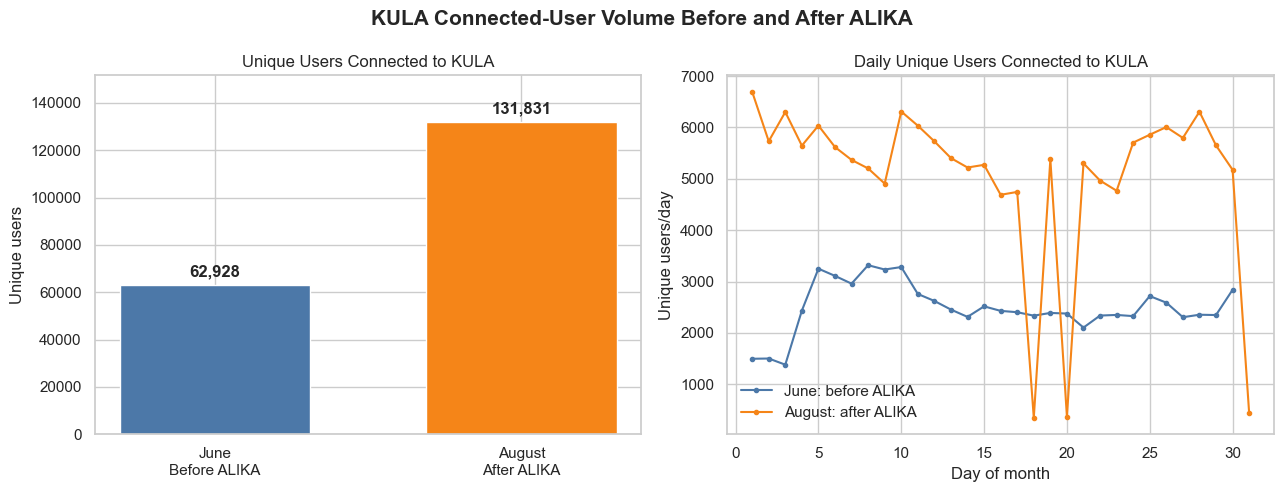

In [20]:
# Visualize connected users and daily KULA traffic.
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
period_colors = ['#4C78A8', '#F58518']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
monthly_users = [data_june_clean['userId'].nunique(), data_august_clean['userId'].nunique()]
labels = ['June\nBefore ALIKA', 'August\nAfter ALIKA']
bars = axes[0].bar(labels, monthly_users, color=period_colors, width=0.62)
axes[0].bar_label(bars, labels=[f'{value:,.0f}' for value in monthly_users], padding=4, fontweight='bold')
axes[0].set_title('Unique Users Connected to KULA')
axes[0].set_ylabel('Unique users')
axes[0].set_ylim(0, max(monthly_users) * 1.15)

june_daily = data_june_clean.groupby('date').agg(unique_users=('userId', 'nunique')).reset_index()
august_daily = data_august_clean.groupby('date').agg(unique_users=('userId', 'nunique')).reset_index()
june_daily['day_of_month'] = pd.to_datetime(june_daily['date']).dt.day
august_daily['day_of_month'] = pd.to_datetime(august_daily['date']).dt.day
axes[1].plot(june_daily['day_of_month'], june_daily['unique_users'], marker='o', markersize=3, label='June: before ALIKA', color=period_colors[0])
axes[1].plot(august_daily['day_of_month'], august_daily['unique_users'], marker='o', markersize=3, label='August: after ALIKA', color=period_colors[1])
axes[1].set_title('Daily Unique Users Connected to KULA')
axes[1].set_xlabel('Day of month')
axes[1].set_ylabel('Unique users/day')
axes[1].legend(frameon=False)

fig.suptitle('KULA Connected-User Volume Before and After ALIKA', fontsize=15, fontweight='bold')
fig.tight_layout()
plt.show()

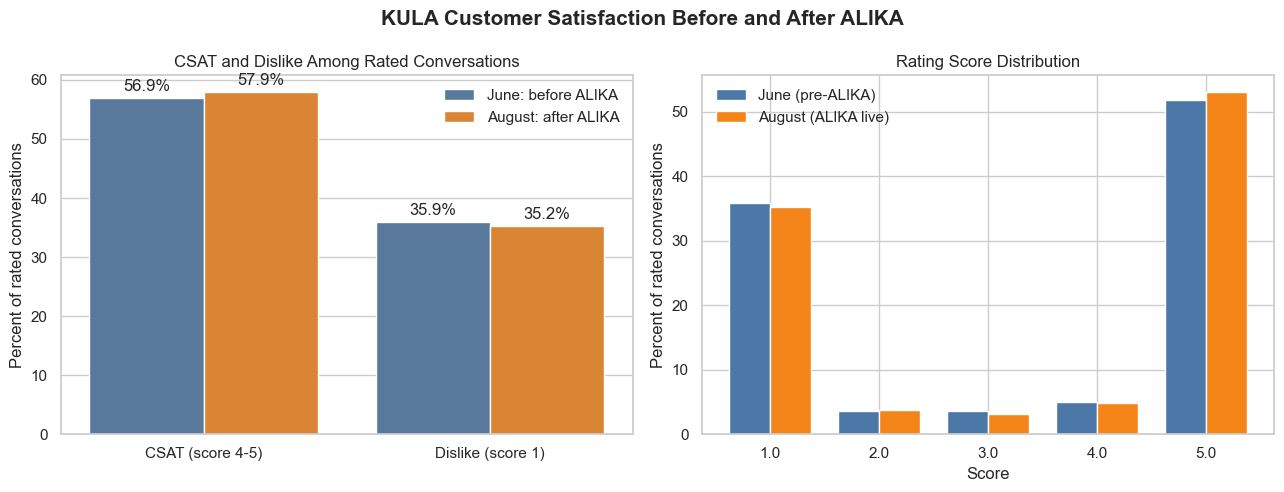

In [21]:
# Visualize quality effects using rates among rated conversations.
quality_plot = pd.DataFrame({
    'Period': ['June: before ALIKA', 'August: after ALIKA'] * 2,
    'Metric': ['CSAT (score 4-5)'] * 2 + ['Dislike (score 1)'] * 2,
    'Percent': [
        100 * june_rated['satisfied'].mean(),
        100 * august_rated['satisfied'].mean(),
        100 * june_rated['dislike'].mean(),
        100 * august_rated['dislike'].mean(),
    ],
})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=quality_plot, x='Metric', y='Percent', hue='Period', palette=period_colors, ax=axes[0])
axes[0].set_title('CSAT and Dislike Among Rated Conversations')
axes[0].set_xlabel('')
axes[0].set_ylabel('Percent of rated conversations')
axes[0].legend(title='', frameon=False)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', padding=3)

rating_distribution.plot(kind='bar', ax=axes[1], color=period_colors, width=0.75)
axes[1].set_title('Rating Score Distribution')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Percent of rated conversations')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(frameon=False)

fig.suptitle('KULA Customer Satisfaction Before and After ALIKA', fontsize=15, fontweight='bold')
fig.tight_layout()
plt.show()